torch needed for jakes pc
pip install torch==2.8.0+cu126  --index-url https://download.pytorch.org/whl/cu126

In [1]:
import torch
from tqdm import tqdm
from torchinfo import summary
import matplotlib.pyplot as plt

from datasets import load_dataset


In [2]:
import data_proc.data_preproc as data_preproc
import dino.dino_features as features

In [3]:
# Run in terminal
# pip install --index-url https://download.pytorch.org/whl/cu126 torch==2.8.0 torchvision

In [4]:
print(torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch cuda version:", torch.version.cuda)
print("compiled with cuda:", torch.backends.cuda.is_built())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

2.8.0+cu126
cuda available: True
torch cuda version: 12.6
compiled with cuda: True
device: cuda


# load model

In [9]:
model = torch.hub.load('facebookresearch/dino:main', 'dino_vits8')
model.eval()

Using cache found in C:\Users\Jake Tallman/.cache\torch\hub\facebookresearch_dino_main


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(8, 8), stride=(8, 8))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
  (head): Identity()
)

In [11]:
summary(model, input_size=(1, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
VisionTransformer                        [1, 384]                  301,824
├─PatchEmbed: 1-1                        [1, 64, 384]              --
│    └─Conv2d: 2-1                       [1, 384, 8, 8]            74,112
├─Dropout: 1-2                           [1, 65, 384]              --
├─ModuleList: 1-3                        --                        --
│    └─Block: 2-2                        [1, 65, 384]              --
│    │    └─LayerNorm: 3-1               [1, 65, 384]              768
│    │    └─Attention: 3-2               [1, 65, 384]              591,360
│    │    └─Identity: 3-3                [1, 65, 384]              --
│    │    └─LayerNorm: 3-4               [1, 65, 384]              768
│    │    └─Mlp: 3-5                     [1, 65, 384]              1,181,568
│    │    └─Identity: 3-6                [1, 65, 384]              --
│    └─Block: 2-3                        [1, 65, 384]         

In [10]:
model.to("cuda")

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(8, 8), stride=(8, 8))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
  (head): Identity()
)

# Tiny Image Net

In [3]:
loader, loader_val = data_preproc.get_dataloaders(data = "tiny_imagenet")

cpu


In [59]:
subsample_percent = 10
model.eval().to(device)

X, y = features.frozen_features(model, loader, device, subsample_percent=None, data_type="tiny_image_net")
X_val, y_val = features.frozen_features(model, loader_val, device, subsample_percent=None, data_type="tiny_image_net")


100%|██████████| 1563/1563 [09:16<00:00,  2.81it/s]


torch.Size([10048, 384]) torch.Size([10048])



100%|██████████| 157/157 [01:06<00:00,  2.37it/s]

torch.Size([1216, 384]) torch.Size([1216])


In [60]:
X.shape, y.shape #These are our class tokens and labels

(torch.Size([10048, 384]), torch.Size([10048]))

In [61]:
from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(X, y)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [62]:
print (y)

tensor([  0,   0,   0,  ..., 199, 199, 199])


In [63]:
print(neigh.predict([X[1200]]))
print(y[1200])

[25]
tensor(25)


In [64]:
neigh.score(X_val, y_val)

# FULL DATA WITH K =5 0.7655

0.4868421052631579

In [1]:
EuroSAT_RGB = load_dataset("blanchon/EuroSAT_RGB")


In [17]:
EuroSAT_RGB

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 16200
    })
    test: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
    validation: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
})

In [14]:
import numpy as np

def std_mean_hf_ds(ds):
    sum_c = np.zeros(3)
    sum_sq_c = np.zeros(3)
    n_pixels = 0

    for img in ds:
        arr = np.array(img['image']) / 255.0  # this is for color data

        pixels = arr.reshape(-1, 3)

        sum_c += pixels.sum(axis=0)
        sum_sq_c += (pixels ** 2).sum(axis=0)
        n_pixels += pixels.shape[0]

    mean = sum_c / n_pixels
    std = np.sqrt(sum_sq_c / n_pixels - mean**2)

    print("mean:", mean)
    print("std:", std)

# EUROSAT

In [28]:
std_mean_hf_ds(EuroSAT_RGB["train"])

mean: [0.31268863 0.34511476 0.37031967]
std: [0.19137047 0.12704164 0.10665024]


<PIL.PngImagePlugin.PngImageFile image mode=RGB size=64x64 at 0x1C2016EB5C0>


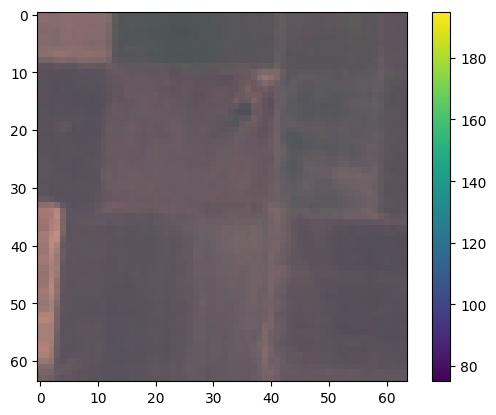

In [26]:
for img in EuroSAT_RGB["train"]:
    print(img['image'])
    plt.imshow(img['image'])
    plt.colorbar()
    break


In [7]:
for batch in loader_val:

    images = batch["image"]
    labels = batch["label"]
    print(images.shape)

    img = images[1].permute(1, 2, 0)#.cpu()

    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)
    plt.colorbar()
    break

NameError: name 'loader_val' is not defined

# UC Merced

In [9]:
UC_Merced_train, UC_Merced_val = data_preproc.get_uc_merced()

<PIL.TiffImagePlugin.TiffImageFile image mode=RGB size=256x256 at 0x1A53D5912B0>


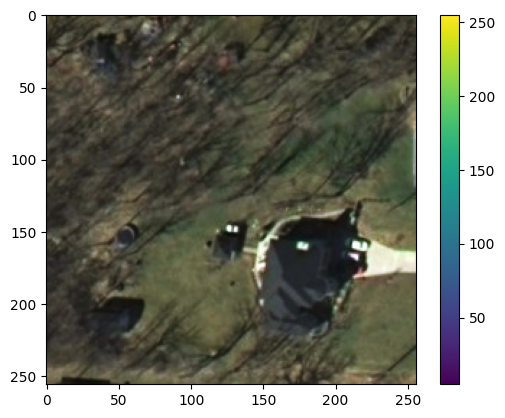

In [12]:
for img in UC_Merced_train:
    print(img['image'])
    plt.imshow(img['image'])
    plt.colorbar()
    break

In [15]:
std_mean_hf_ds(UC_Merced_train)

mean: [0.48368496 0.48899795 0.44999416]
std: [0.21761176 0.2016371  0.19559446]
